In [ ]:
import glob
import json
import pickle
from retrieval_embedding_module import InstanceSampleNli

dataset = "RAWFC"
input_dir = "nli_relations_r10-s5_deberta-large"
data_split = "train"
data = {}
id2label_map = json.load(open(f"{input_dir}/id2lab_map.json", "r"))
classification_label2id_map = json.load(
	open(f"{input_dir}/{dataset}/classification_lab2id_map.json", "r")
)
for file in glob.glob(f"{input_dir}/{dataset}/{data_split}/*.pkl"):
	sample_id = file.split("/")[-1].removesuffix(".pkl")
	data[sample_id]: InstanceSampleNli = pickle.load(open(file, "rb"))

In [7]:
from collections import Counter, defaultdict

nli_label_stats = []
combined_nli_label_stats = Counter()
sample_level_counts = defaultdict(list)
for sample_id, sample_data in data.items():
	sample_stats = Counter({"entailment": 0, "neutral": 0, "contradiction": 0})
	for nli_data in sample_data.nli_tuples:
		nli_label = id2label_map[str(nli_data[2])]
		sample_stats[nli_label] += 1

	nli_total = sample_stats.total()
	for key, val in sample_stats.items():
		combined_nli_label_stats[key] += val
		sample_stats[key] = val / nli_total

	for nli_lab, val in sample_stats.items():
		nli_label_stats += [
			{
				"label": sample_data.gt_label.title(),
				"nli_lab": nli_lab,
				"nli_val": val,
				"id": sample_id,
			}
		]
		sample_level_counts[sample_id] = {
			"nli_dist": dict(sample_stats),
			"gt_label": sample_data.gt_label,
		}
combined_nli_total = combined_nli_label_stats.total()
for key, val in combined_nli_label_stats.items():
	combined_nli_label_stats[key] = val / combined_nli_total

In [8]:
for l in sample_level_counts.values():
	print(l)

{'nli_dist': {'entailment': 0.8, 'neutral': 0.01, 'contradiction': 0.19}, 'gt_label': 'true'}
{'nli_dist': {'entailment': 0.65, 'neutral': 0.2, 'contradiction': 0.15}, 'gt_label': 'true'}
{'nli_dist': {'entailment': 0.89, 'neutral': 0.01, 'contradiction': 0.1}, 'gt_label': 'half'}
{'nli_dist': {'entailment': 0.86, 'neutral': 0.01, 'contradiction': 0.13}, 'gt_label': 'false'}
{'nli_dist': {'entailment': 0.43, 'neutral': 0.03, 'contradiction': 0.54}, 'gt_label': 'false'}
{'nli_dist': {'entailment': 0.6, 'neutral': 0.07, 'contradiction': 0.33}, 'gt_label': 'false'}
{'nli_dist': {'entailment': 0.58, 'neutral': 0.23, 'contradiction': 0.19}, 'gt_label': 'false'}
{'nli_dist': {'entailment': 0.47, 'neutral': 0.29, 'contradiction': 0.24}, 'gt_label': 'true'}
{'nli_dist': {'entailment': 0.81, 'neutral': 0.02, 'contradiction': 0.17}, 'gt_label': 'half'}
{'nli_dist': {'entailment': 0.36, 'neutral': 0.37, 'contradiction': 0.27}, 'gt_label': 'half'}
{'nli_dist': {'entailment': 0.24, 'neutral': 0.3, 

In [9]:
s = pickle.load(open("nli_relations_r10-s5_deberta-large/LIAR-RAW/test/8963.pkl", "rb"))
num_sents = 0
for report_idx, sent_idx in s.reports_content.items():
	num_sents += len(sent_idx)
	print(f"{report_idx}: {[s.sentence_texts[s_idx]['text'] for s_idx in sent_idx]}")
print(num_sents)

nli_lab = Counter()
for p, h, lab, prob in s.nli_tuples:
	if h != -1:
		continue
	nli_lab[lab] += 1
nli_lab

26: ['be/XbB_002qEhc `` Mitch McConnell vote with Harry Reid to infringe on our gun right .', 'Joseph Gerth @ Joe_Gerth In the ad , which air only on cable television , accuse McConnell of vote like Democratic Majority Leader Harry Reid on gun issue .', "To back up it claim , the Bevin campaign cite McConnell 's vote for the crime bill in 1991 , which include provision to impose a waiting period for handgun purchase and a ban on assault rifle ."]
28: ['Harry Reid say Carson deserve a vote on anti-gun violence legislation .', 'Reid say he plan showdown vote on gun control on Thursday .', '” Before the vote , Senate Minority Leader Mitch McConnell , R-Ky .', 'The vote come four month after a gunman kill 20 first-graders and six staffer at Sandy Hook Elementary School in Newtown , spur Obama and legislator to attempt to address firearm violence .', 'Scott Applewhite ) WASHINGTON — Watched by tearful relative of Newtown school massacre victim , gun control supporter in the Senate win the f

Counter({1: 4, 0: 3, 2: 3})

In [10]:
s = pickle.load(open("nli_relations_r10-s5_deberta-large/LIAR-RAW/test/8963.pkl", "rb"))
num_sents = 0
for report_idx, sent_idx in s.reports_content.items():
	num_sents += len(sent_idx)
	print(f"{report_idx}: {[s.sentence_texts[s_idx]['is_evidence'] for s_idx in sent_idx]}")
print(num_sents)

26: [1, 0, 0]
28: [1, 0, 1, 0, 0]
29: [0, 0]
17: [1, 0, 1, 0, 0]
1: [1, 0, 0]
25: [0, 0]
2: [0, 0, 0, 0]
19: [0, 0, 0]
12: [0, 0, 0, 0, 0]
6: [0, 0, 0, 0, 0]
37


In [11]:
sorted_sample_counts = dict(
	sorted(sample_level_counts.items(), key=lambda x: x[1]["nli_dist"]["entailment"], reverse=True)
)

for sample_id, sample_data_count in sorted_sample_counts.items():
	if sample_data_count["gt_label"] != "false":
		continue
	print(sample_id, sample_data_count)

261386 {'nli_dist': {'entailment': 0.98, 'neutral': 0.02, 'contradiction': 0.0}, 'gt_label': 'false'}
233368 {'nli_dist': {'entailment': 0.98, 'neutral': 0.0, 'contradiction': 0.02}, 'gt_label': 'false'}
244169 {'nli_dist': {'entailment': 0.96, 'neutral': 0.01, 'contradiction': 0.03}, 'gt_label': 'false'}
243635 {'nli_dist': {'entailment': 0.96, 'neutral': 0.0, 'contradiction': 0.04}, 'gt_label': 'false'}
233991 {'nli_dist': {'entailment': 0.96, 'neutral': 0.04, 'contradiction': 0.0}, 'gt_label': 'false'}
252755 {'nli_dist': {'entailment': 0.95, 'neutral': 0.0, 'contradiction': 0.05}, 'gt_label': 'false'}
193777 {'nli_dist': {'entailment': 0.95, 'neutral': 0.02, 'contradiction': 0.03}, 'gt_label': 'false'}
270479 {'nli_dist': {'entailment': 0.95, 'neutral': 0.0, 'contradiction': 0.05}, 'gt_label': 'false'}
244255 {'nli_dist': {'entailment': 0.94, 'neutral': 0.05, 'contradiction': 0.01}, 'gt_label': 'false'}
242281 {'nli_dist': {'entailment': 0.94, 'neutral': 0.04, 'contradiction': 0.02

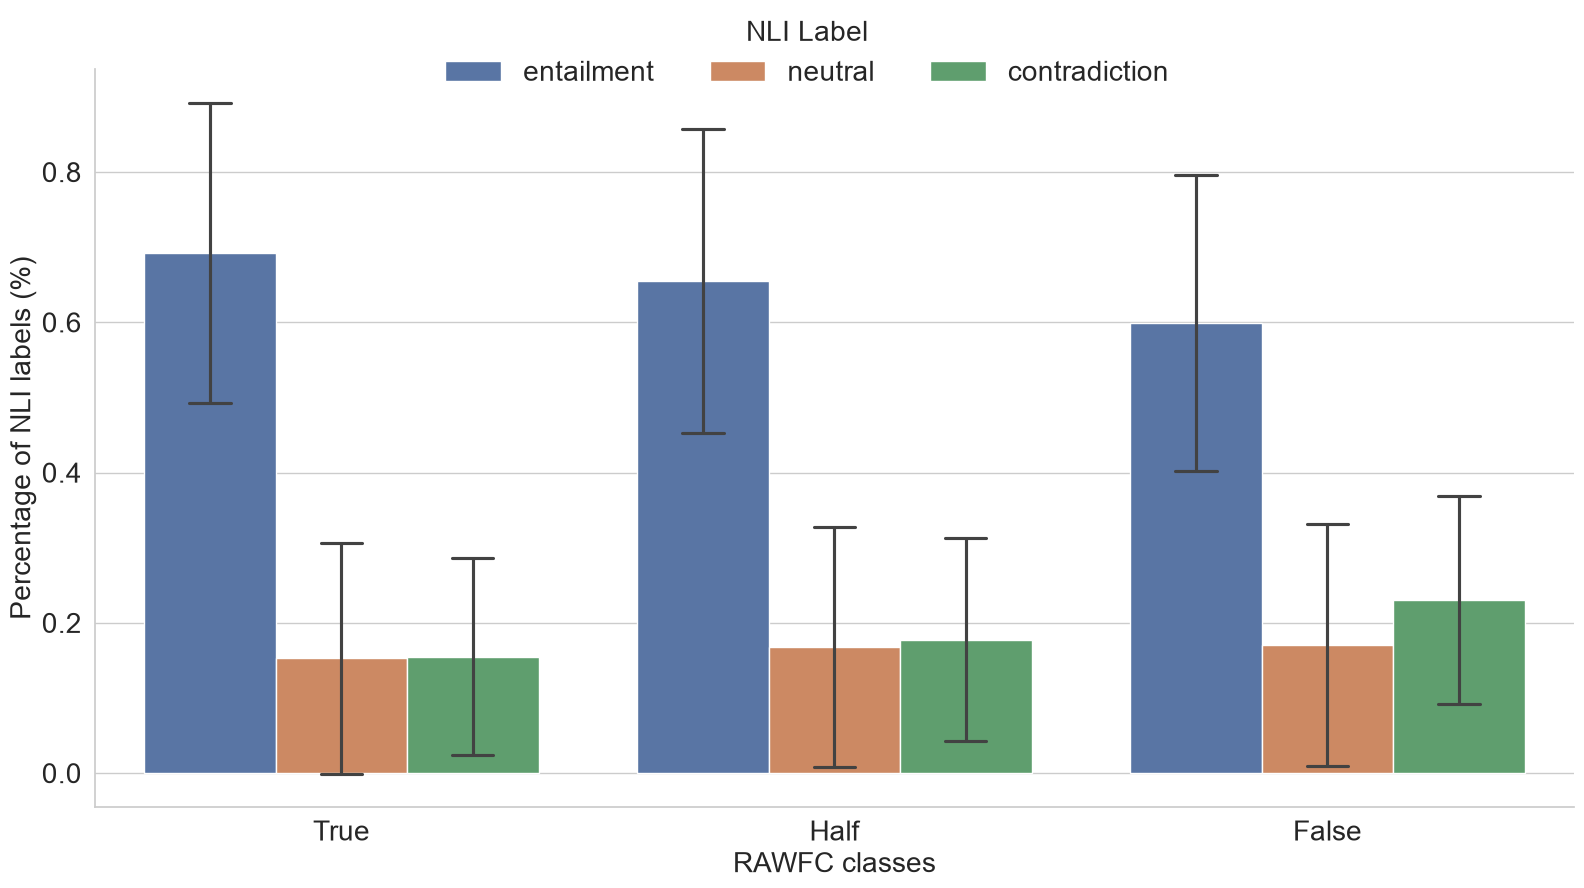

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(nli_label_stats)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 9))

fig = sns.barplot(df, x="label", y="nli_val", fill=True, hue="nli_lab", errorbar="sd", capsize=0.25)
# sns.stripplot(df, x="label", y="nli_val", hue="nli_lab", dodge=True, legend=False)
plt.legend(
	frameon=False,
	ncols=3,
	bbox_to_anchor=(0.22, 1.1),
	loc="upper left",
	title="NLI Label",
	fontsize=20,
	title_fontsize=20,
)
plt.xlabel(f"{dataset} classes", fontsize=20)
plt.ylabel("Percentage of NLI labels (%)", fontsize=20)
plt.tick_params(labelsize=20, axis="both")
sns.despine()
plt.tight_layout()
plt.show()
# fig.figure.savefig(f"nli_distribution_{dataset}.pdf", transparent=True)